In [3]:
import sys, os, requests
sys.path.append('./official/DISCoVeR-main/src/')

import scanpy as sc
import anndata as ad

from metrics import kmeans_ari
from NBVAE_variants import ZINBVAE, ZINBCVAE, ZINBCSVAENA, ZINBCSVAE, ZINBHCSVAENA, ZINBHCSVAE, ZINBDLVAE, ZINBDIVA, ZINBCCVAE
from VAE_trainers import EpochPyroTrainer, AdversarialEpochPyroTrainer, ThresholdPyroTrainer, AdversarialThresholdPyroTrainer
# Slavutsky et al. (2025)
# Full citation in external folder

from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import seaborn as sns

from tqdm import trange, tqdm
from umap import UMAP


import torch, pyro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import pyro.optim as opt

np.random.seed(42)
torch.manual_seed(42)
pyro.util.set_rng_seed(42)


cmap_trt = LinearSegmentedColormap.from_list("cmap", ["#42378C", "#D9A404"])
cmap_ct = ListedColormap(sns.color_palette('colorblind').as_hex())

## Data

In [4]:
import os, requests
# Static data path, update when necessary
DATA_PATH = "https://www.dropbox.com/scl/fi/zxta2nf00p8a9do907rrv/kang_et_al_perturtbations_preprocessed.h5ad?rlkey=bk4pbuily0349borou6rnvjds&st=yvp1zxjd&dl=1"
NAME = "kang_et_al_perturtbations_preprocessed.h5ad"


# Reorganize param paths
save_path = "./data/" + NAME

# Send download request
headers = {
    "user-agent": "Wget/1.16 (linux-gnu)"
}  # Dropbox checks the agent for some reason
response = requests.get(
    DATA_PATH, headers=headers, stream=True, allow_redirects=True
)

# Get and process response

## Good
if response.status_code == 200:
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Write with progress bar
    with tqdm(
        total=int(response.headers.get("content-length", 0)),
        unit="B",
        unit_scale=True,
    ) as progress_bar:
        with open(save_path, "wb") as f:
            for data in response.iter_content(1024):
                progress_bar.update(len(data))
                f.write(data)

    print(f"Object saved at {save_path}")

## Unexpected
else:
    print(response.__dict__)
    raise Exception("Object not found at URL")

100%|███████████████████████████████████████████████████████████████████████████████| 342M/342M [00:29<00:00, 11.6MB/s]

Object saved at ./data/kang_et_al_perturtbations_preprocessed.h5ad


In [5]:
# This is skipped, but left to describe preprocessing.
# If you need the raw data for anything, the SeuratData package has it. Check here for more details: https://satijalab.org/seurat/archive/v3.2/immune_alignment.html

# if not os.path.exists('./data/kang_et_al_perturtbations_preprocessed.h5ad'):
    # anndata = ad.read_h5ad('./data/kang_et_al_perturtbations.h5ad')
    # anndata.layers['raw'] = anndata.X.copy()
      
    # map_dict = {
    #     'B' : 'B', 
    #     'B Activated' : 'B', 
    #     'CD4 Memory T' : 'CD4 T', 
    #     'CD4 Naive T': 'CD4 T', 
    #     'CD8 T': 'CD8 T', 
    #     'CD14 Mono': 'CD14 Mono',
    #     'CD16 Mono': 'CD16 Mono', 
    #     'DC': 'DC', 
    #     'Eryth': 'Eryth', 
    #     'Mk': 'Mk', 
    #     'NK': 'NK', 
    #     'T activated': 'T', 
    #     'pDC': 'DC',
    # }
        
    # anndata.obs['seurat_annotations'] = anndata.obs['seurat_annotations'].astype(object).apply(lambda x: map_dict[x]).astype('category')    
      
    # sc.pp.filter_cells(anndata, min_genes=200)
    # sc.pp.filter_genes(anndata, min_cells=3)
    # sc.pp.normalize_total(anndata)
    # sc.pp.log1p(anndata)
    
#     sc.pp.highly_variable_genes(anndata, n_top_genes=2000)
#     anndata = anndata[:, anndata.var['highly_variable']]
    
#     anndata.write_h5ad('./data/kang_et_al_perturtbations_preprocessed.h5ad')
    
# else:

anndata = ad.read_h5ad('./data/kang_et_al_perturtbations_preprocessed.h5ad')

In [6]:
anndata

AnnData object with n_obs × n_vars = 13999 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stim', 'seurat_annotations', 'n_genes'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'raw'
    obsp: 'connectivities', 'distances'

In [7]:
import torch.utils.data as utils

np.random.seed(42)
torch.manual_seed(42)
pyro.util.set_rng_seed(42)

batch_size=128
x = torch.FloatTensor(anndata.layers['raw'].copy())
y = torch.FloatTensor(anndata.obs['stim'].cat.codes.to_numpy().reshape(-1,1).copy())
y_info = torch.FloatTensor(anndata.obs['seurat_annotations'].cat.codes.to_numpy().reshape(-1,1).copy())

dataset = utils.TensorDataset(x, y, y_info)
train_set, test_set = dataset, dataset
train_set, test_set = utils.TensorDataset(*train_set[:]), utils.TensorDataset(*test_set[:])
train_loader, test_loader  = torch.utils.data.DataLoader(train_set, shuffle=True, batch_size=batch_size),  torch.utils.data.DataLoader(test_set, shuffle=True, batch_size=batch_size)

In [8]:
y

tensor([[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [1.],
        [1.]])

In [9]:
reducer = UMAP(random_state=0, metric='correlation')
umap_data = reducer.fit_transform(np.log1p(np.array(test_set[:][0])))

C:\Users\anany\miniconda3\envs\ds_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\anany\miniconda3\envs\ds_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [10]:
from pyfonts import load_font

# load font
font = load_font(
   font_url="https://github.com/stevenpetryk/computer-modern/blob/main/src/cmunrm.ttf?raw=true"
)

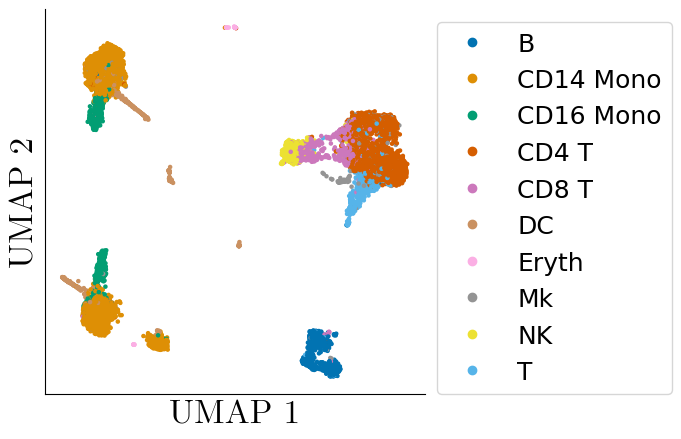

In [26]:
plt.figure(figsize=(10,5))

scatter = plt.scatter(umap_data[:, 0], umap_data[:, 1], c=test_set[:][2], cmap=cmap_ct, s=5, alpha=1)


plt.gca().set_aspect('equal')
plt.yticks([])
plt.xticks([])
plt.gca().spines[['right', 'top']].set_visible(False)


plt.ylabel('UMAP 2', fontsize=24, font=font)
plt.xlabel('UMAP 1', fontsize=24, font=font)

leg = plt.legend(handles=scatter.legend_elements()[0], labels=list(anndata.obs['seurat_annotations'].cat.categories), fontsize=18, bbox_to_anchor=(1, 1))


plt.show()

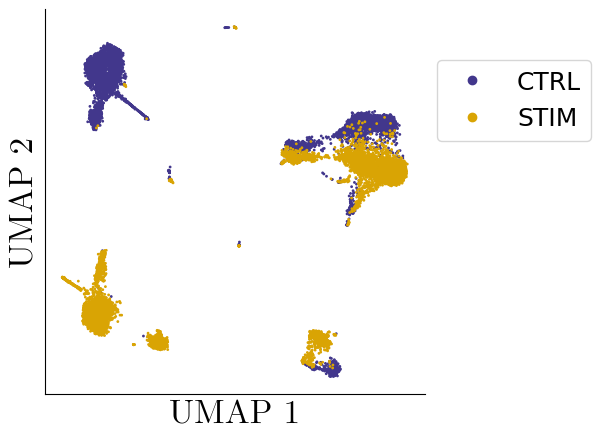

In [28]:
plt.figure(figsize=(10,5))


scatter = plt.scatter(umap_data[:, 0], umap_data[:, 1], c=test_set[:][1], cmap=cmap_trt, s=1)

plt.gca().set_aspect('equal')
plt.yticks([])
plt.xticks([])
plt.gca().spines[['right', 'top']].set_visible(False)

plt.ylabel('UMAP 2', font=font, fontsize=24)
plt.xlabel('UMAP 1', font=font, fontsize=24)

plt.legend(handles=scatter.legend_elements()[0], labels=list(anndata.obs['stim'].cat.categories), fontsize=18, bbox_to_anchor=(1, 0.9))

plt.show()

## CSVAE - No Adv.

In [10]:
np.random.seed(42)
torch.manual_seed(42)
pyro.util.set_rng_seed(42)

csvaena = ZINBCSVAENA(2000, [1], latent_dim=10, w_dim=2, num_layers=1, hidden_dim=128, recon_weight=1, z_kl_weight=1e-4, w_kl_weight=1)
csvaena_trainer = ThresholdPyroTrainer(0, 50, csvaena, train_loader, test_loader, opt.AdamW({"lr": 1e-3}))
csvaena_trainer.train()

Epoch : 1 || Train Loss: 692.67 || Test Loss: 421.159
Epoch : 2 || Train Loss: 400.44 || Test Loss: 390.985
New minimum attained, resetting patience...
Epoch : 3 || Train Loss: 384.711 || Test Loss: 378.62
New minimum attained, resetting patience...
Epoch : 4 || Train Loss: 374.235 || Test Loss: 370.278
New minimum attained, resetting patience...
Epoch : 5 || Train Loss: 368.892 || Test Loss: 365.874
New minimum attained, resetting patience...
Epoch : 6 || Train Loss: 365.438 || Test Loss: 364.364
New minimum attained, resetting patience...
Epoch : 7 || Train Loss: 362.427 || Test Loss: 360.036
New minimum attained, resetting patience...
Epoch : 8 || Train Loss: 360.738 || Test Loss: 360.58
Epoch : 9 || Train Loss: 358.582 || Test Loss: 356.339
New minimum attained, resetting patience...
Epoch : 10 || Train Loss: 357.54 || Test Loss: 355.296
New minimum attained, resetting patience...
Epoch : 11 || Train Loss: 355.567 || Test Loss: 352.747
New minimum attained, resetting patience...
Ep

In [11]:
preds = csvaena_trainer.get_variables('test')
z_s = preds['z'][0].cpu()
w_s = preds['w'][0].cpu()
recons = preds['rec'][0].cpu()

320.2662353515625


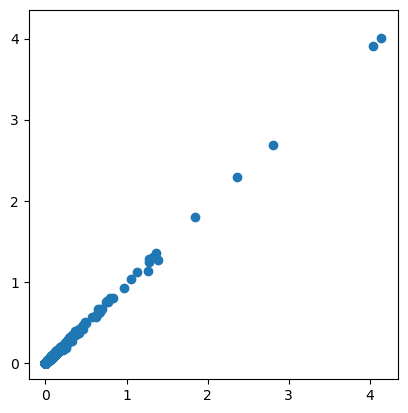

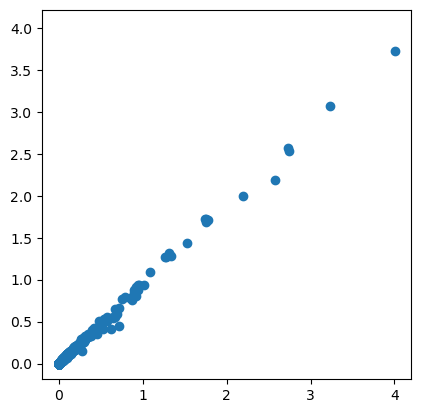

In [12]:
trace = csvaena_trainer.get_trace('test')
print(-1 * trace.nodes['rec']['fn'].log_prob(test_set[:][0]).mean().item())
plt.figure()
plt.scatter(test_set[:][0].log1p().mean(dim=0), recons.log1p().mean(dim=0))
plt.gca().axis('square')

plt.figure()
plt.scatter(test_set[:][0].log1p().var(dim=0), recons.log1p().var(dim=0))
plt.gca().axis('square')


plt.show()

In [13]:
reducer = UMAP()
z_s = reducer.fit_transform(z_s)

C:\Users\anany\miniconda3\envs\ds_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


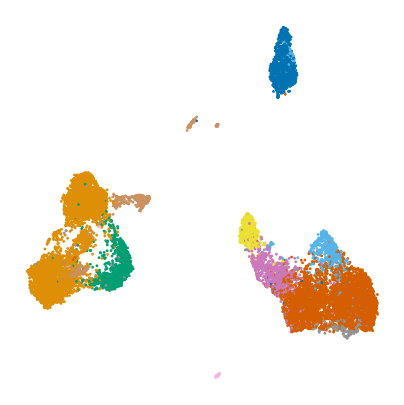

In [14]:
plt.figure(figsize=(5,5))

plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.axis('off')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())

plt.show()

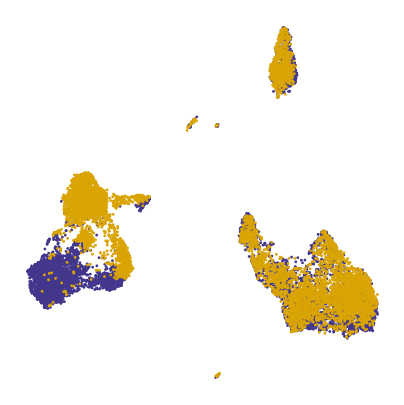

In [15]:
plt.figure(figsize=(5,5))

plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.axis('off')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())

plt.show()

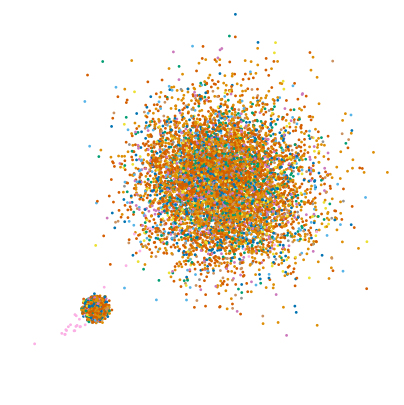

In [16]:
plt.figure(figsize=(5,5))

plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.axis('off')
plt.gca().set_aspect('equal')
plt.ylim(-2,7)
plt.xlim(-2,7)
plt.show()

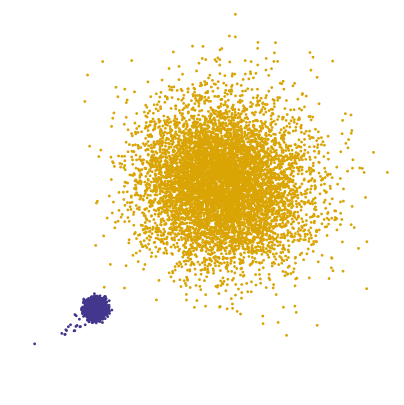

In [17]:
plt.figure(figsize=(5,5))

plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.axis('off')
plt.gca().set_aspect('equal')
plt.ylim(-2,7)
plt.xlim(-2,7)
plt.show()

## CSVAE

In [18]:
np.random.seed(42)
torch.manual_seed(42)
pyro.util.set_rng_seed(42)

csvae = ZINBCSVAE(2000, [1], latent_dim=10, w_dim=2, num_layers=1, hidden_dim=128, recon_weight=1, z_kl_weight=1e-4, w_kl_weight=1, adversarial_weight=1e2)
csvae_trainer = AdversarialThresholdPyroTrainer(0, 50, 1, 1, csvae, train_loader, test_loader, opt.AdamW({"lr": 1e-3}))
csvae_trainer.train()
# csvae_trainer.save('params/Kang/csvae_kang')

Epoch : 1 || Train Loss: 615.946 || Test Loss: 359.178 || Classifier Loss: 0.607
Epoch : 2 || Train Loss: 342.381 || Test Loss: 329.749 || Classifier Loss: 0.674
New minimum attained, resetting patience...
Epoch : 3 || Train Loss: 322.397 || Test Loss: 315.2 || Classifier Loss: 0.699
New minimum attained, resetting patience...
Epoch : 4 || Train Loss: 310.802 || Test Loss: 305.684 || Classifier Loss: 0.663
New minimum attained, resetting patience...
Epoch : 5 || Train Loss: 305.259 || Test Loss: 302.407 || Classifier Loss: 0.663
New minimum attained, resetting patience...
Epoch : 6 || Train Loss: 301.256 || Test Loss: 299.146 || Classifier Loss: 0.654
New minimum attained, resetting patience...
Epoch : 7 || Train Loss: 298.572 || Test Loss: 296.799 || Classifier Loss: 0.652
New minimum attained, resetting patience...
Epoch : 8 || Train Loss: 296.624 || Test Loss: 294.572 || Classifier Loss: 0.677
New minimum attained, resetting patience...
Epoch : 9 || Train Loss: 294.73 || Test Loss: 

RuntimeError: Parent directory params/Kang does not exist.

In [19]:
preds = csvae_trainer.get_variables('test')
z_s = preds['z'][0].cpu()
w_s = preds['w'][0].cpu()
recons = preds['rec'][0].cpu()

325.5150451660156


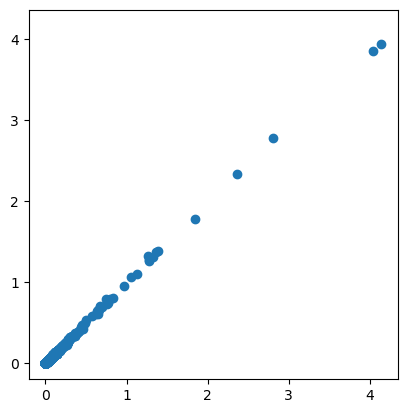

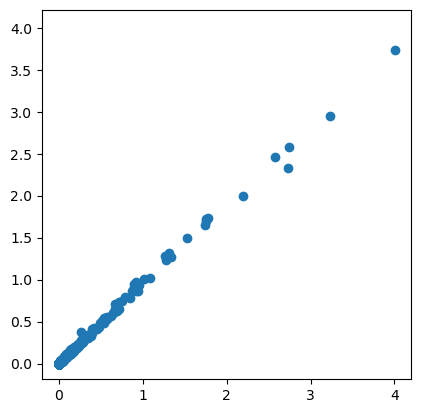

In [20]:
trace = csvae_trainer.get_trace('test')
print(-1 * trace.nodes['rec']['fn'].log_prob(test_set[:][0]).mean().item())
plt.figure()
plt.scatter(test_set[:][0].log1p().mean(dim=0), recons.log1p().mean(dim=0))
plt.gca().axis('square')

plt.figure()
plt.scatter(test_set[:][0].log1p().var(dim=0), recons.log1p().var(dim=0))
plt.gca().axis('square')


plt.show()

In [21]:
reducer = UMAP()
z_s = reducer.fit_transform(z_s)

C:\Users\anany\miniconda3\envs\ds_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


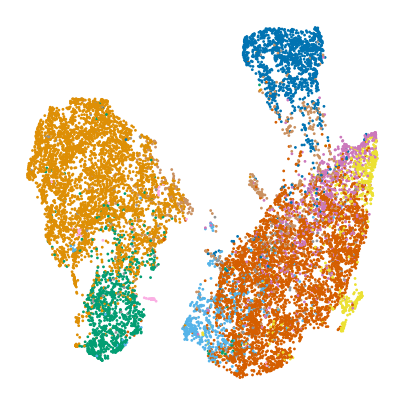

In [22]:
plt.figure(figsize=(5,5))
plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.axis('off')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.show()

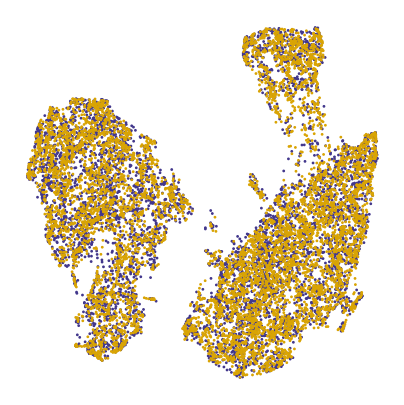

In [23]:
plt.figure(figsize=(5,5))
plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.axis('off')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.show()

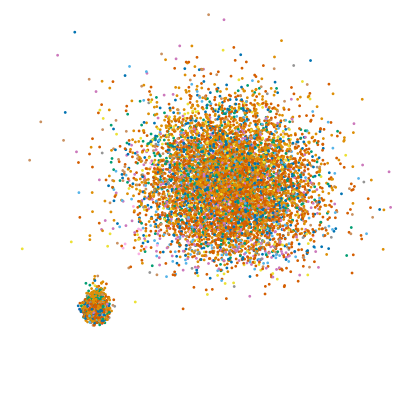

In [24]:
plt.figure(figsize=(5,5))
plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.axis('off')
plt.ylim(-2,7)
plt.xlim(-2,7)

plt.gca().set_aspect(1/plt.gca().get_data_ratio())


plt.show()

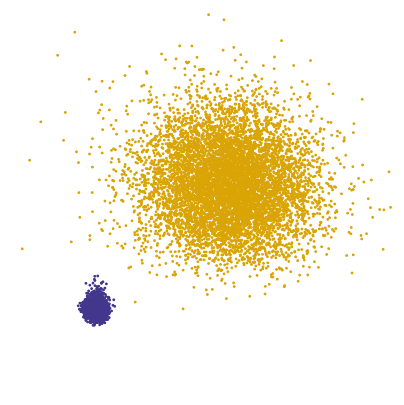

In [25]:
plt.figure(figsize=(5,5))
plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.axis('off')
plt.ylim(-2,7)
plt.xlim(-2,7)

plt.gca().set_aspect(1/plt.gca().get_data_ratio())

plt.show()

## HCSVAE - No Adv.

In [26]:
np.random.seed(42)
torch.manual_seed(42)
pyro.util.set_rng_seed(42)

hcsvaena = ZINBHCSVAENA(2000, [1], latent_dim=10, w_dim=2, num_layers=1, hidden_dim=128, recon_weight=1, z_kl_weight=1e-4, w_kl_weight=1)
hcsvaena_trainer = ThresholdPyroTrainer(0, 50, hcsvaena, train_loader, test_loader, opt.AdamW({"lr": 1e-3}))
hcsvaena_trainer.train()

Epoch : 1 || Train Loss: 689.022 || Test Loss: 2554.143
Epoch : 2 || Train Loss: 405.992 || Test Loss: 628445.903
Epoch : 3 || Train Loss: 389.117 || Test Loss: 405.562
New minimum attained, resetting patience...
Epoch : 4 || Train Loss: 379.03 || Test Loss: 8220.611
Epoch : 5 || Train Loss: 370.596 || Test Loss: 372.672
New minimum attained, resetting patience...
Epoch : 6 || Train Loss: 365.717 || Test Loss: 361.625
New minimum attained, resetting patience...
Epoch : 7 || Train Loss: 362.885 || Test Loss: 363.338
Epoch : 8 || Train Loss: 360.603 || Test Loss: 358.428
New minimum attained, resetting patience...
Epoch : 9 || Train Loss: 358.389 || Test Loss: 364.534
Epoch : 10 || Train Loss: 356.118 || Test Loss: 352.598
New minimum attained, resetting patience...
Epoch : 11 || Train Loss: 355.465 || Test Loss: 353.003
Epoch : 12 || Train Loss: 353.577 || Test Loss: 351.504
New minimum attained, resetting patience...
Epoch : 13 || Train Loss: 352.513 || Test Loss: 349.469
New minimum a

In [27]:
preds = hcsvaena_trainer.get_variables('test')
z_s = preds['z'][0].cpu()
w_s = preds['w'][0].cpu()
recons = preds['rec'][0].cpu()

331.5924987792969


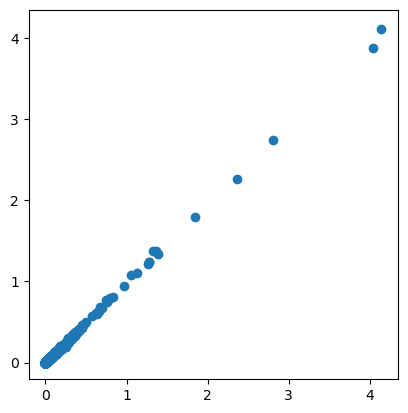

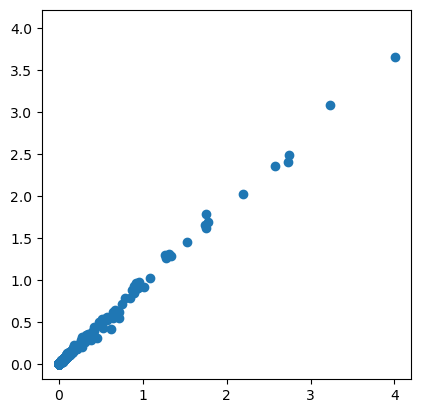

In [28]:
trace = hcsvaena_trainer.get_trace('test')
print(-1 * trace.nodes['rec']['fn'].log_prob(test_set[:][0]).mean().item())
plt.figure()
plt.scatter(test_set[:][0].log1p().mean(dim=0), recons.log1p().mean(dim=0))
plt.gca().axis('square')

plt.figure()
plt.scatter(test_set[:][0].log1p().var(dim=0), recons.log1p().var(dim=0))
plt.gca().axis('square')


plt.show()

In [29]:
reducer = UMAP()
z_s = reducer.fit_transform(z_s)

C:\Users\anany\miniconda3\envs\ds_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


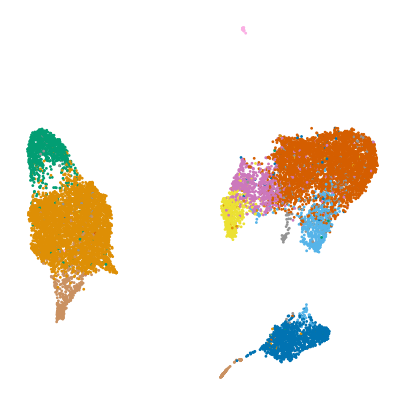

In [30]:
plt.figure(figsize=(5,5))
plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.axis('off')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())

plt.show()

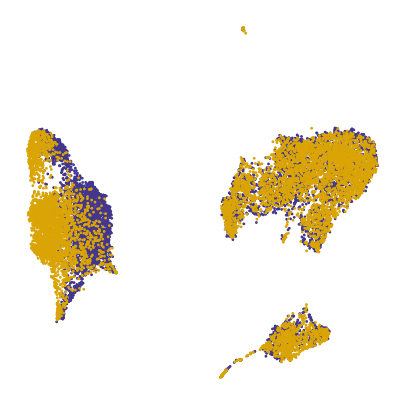

In [31]:
plt.figure(figsize=(5,5))
plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.axis('off')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())

plt.show()

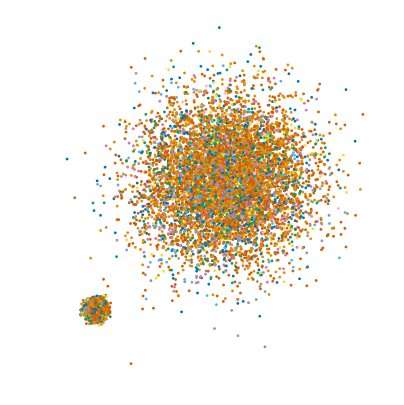

In [32]:
plt.figure(figsize=(5,5))

plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.axis('off')
plt.ylim(-2,7)
plt.xlim(-2,7)

plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.show()

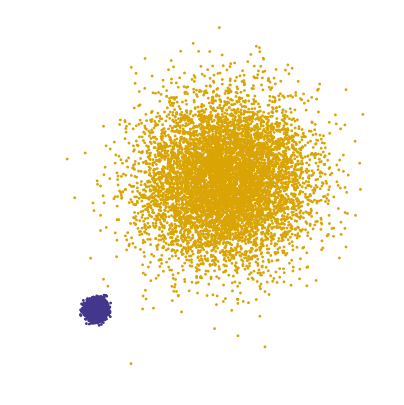

In [33]:
plt.figure(figsize=(5,5))

plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.axis('off')
plt.ylim(-2,7)
plt.xlim(-2,7)

plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.show()

## HCSVAE

In [34]:
np.random.seed(42)
torch.manual_seed(42)
pyro.util.set_rng_seed(42)

hcsvae = ZINBHCSVAE(2000, [1], latent_dim=10, w_dim=2, num_layers=1, hidden_dim=128, recon_weight=1, z_kl_weight=1e-4, w_kl_weight=1 ,adversarial_weight=1e2)
hcsvae_trainer = AdversarialThresholdPyroTrainer(0, 50, 1, 1, hcsvae, train_loader, test_loader, opt.AdamW({"lr": 1e-3}))
hcsvae_trainer.train()

Epoch : 1 || Train Loss: 610.012 || Test Loss: 5134.158 || Classifier Loss: 0.693
Epoch : 2 || Train Loss: 344.1 || Test Loss: 99476.28 || Classifier Loss: 0.672
Epoch : 3 || Train Loss: 335.857 || Test Loss: 7980.848 || Classifier Loss: 0.626
Epoch : 4 || Train Loss: 318.909 || Test Loss: 421.881 || Classifier Loss: 0.661
New minimum attained, resetting patience...
Epoch : 5 || Train Loss: 312.096 || Test Loss: 315.637 || Classifier Loss: 0.661
New minimum attained, resetting patience...
Epoch : 6 || Train Loss: 308.114 || Test Loss: 387.988 || Classifier Loss: 0.672
Epoch : 7 || Train Loss: 304.982 || Test Loss: 303.399 || Classifier Loss: 0.678
New minimum attained, resetting patience...
Epoch : 8 || Train Loss: 302.511 || Test Loss: 297.593 || Classifier Loss: 0.666
New minimum attained, resetting patience...
Epoch : 9 || Train Loss: 300.05 || Test Loss: 297.74 || Classifier Loss: 0.679
Epoch : 10 || Train Loss: 298.109 || Test Loss: 295.062 || Classifier Loss: 0.683
New minimum at

In [35]:
preds = hcsvae_trainer.get_variables('test')
z_s = preds['z'][0].cpu()
w_s = preds['w'][0].cpu()
rho_s = preds['rho'][0].cpu()
recons = preds['rec'][0].cpu()

331.7008361816406


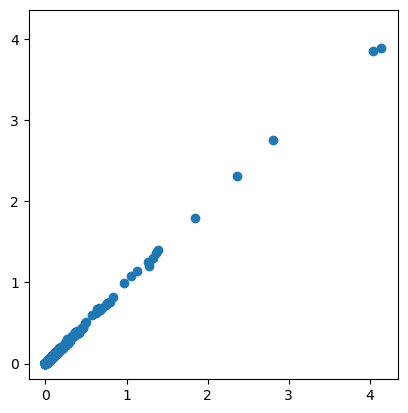

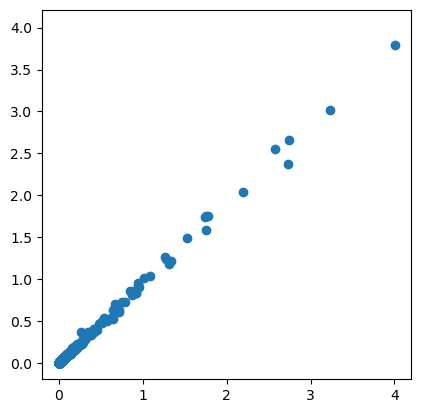

In [36]:
trace = hcsvae_trainer.get_trace('test')
print(-1 * trace.nodes['rec']['fn'].log_prob(test_set[:][0]).mean().item())
plt.figure()
plt.scatter(test_set[:][0].log1p().mean(dim=0), recons.log1p().mean(dim=0))
plt.gca().axis('square')

plt.figure()
plt.scatter(test_set[:][0].log1p().var(dim=0), recons.log1p().var(dim=0))
plt.gca().axis('square')


plt.show()

In [37]:
reducer = UMAP()
z_s = reducer.fit_transform(z_s)

C:\Users\anany\miniconda3\envs\ds_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [1]:
plt.figure(figsize=(5,5))
plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.axis('off')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())

plt.show()

NameError: name 'plt' is not defined

In [2]:
plt.figure(figsize=(5,5))
plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.axis('off')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())

plt.show()

NameError: name 'plt' is not defined

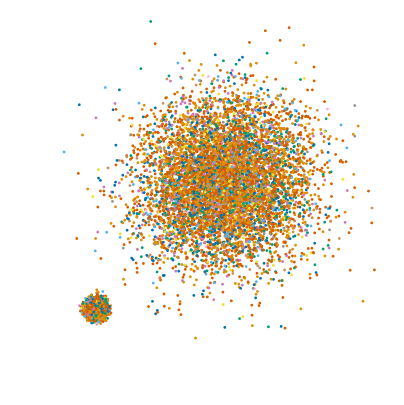

In [40]:
plt.figure(figsize=(5,5))
plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.axis('off')
plt.ylim(-2,7)
plt.xlim(-2,7)

plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.show()

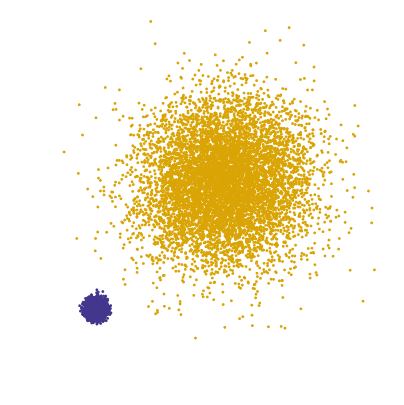

In [41]:
plt.figure(figsize=(5,5))
plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.axis('off')
plt.ylim(-2,7)
plt.xlim(-2,7)

plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.show()

## DIVA

In [42]:
np.random.seed(42)
torch.manual_seed(42)
pyro.util.set_rng_seed(42)

diva = ZINBDIVA(2000, [1], latent_dim=10, w_dim=2, num_layers=1, hidden_dim=128, recon_weight=1, kl_weight=1e-4)
diva_trainer = ThresholdPyroTrainer(0, 50, diva, train_loader, test_loader, opt.AdamW({"lr": 1e-3}))
diva_trainer.train()

Epoch : 1 || Train Loss: 664.389 || Test Loss: 414.428
Epoch : 2 || Train Loss: 399.296 || Test Loss: 386.745
New minimum attained, resetting patience...
Epoch : 3 || Train Loss: 379.234 || Test Loss: 374.66
New minimum attained, resetting patience...
Epoch : 4 || Train Loss: 370.371 || Test Loss: 365.028
New minimum attained, resetting patience...
Epoch : 5 || Train Loss: 364.377 || Test Loss: 361.028
New minimum attained, resetting patience...
Epoch : 6 || Train Loss: 361.348 || Test Loss: 359.094
New minimum attained, resetting patience...
Epoch : 7 || Train Loss: 358.564 || Test Loss: 355.879
New minimum attained, resetting patience...
Epoch : 8 || Train Loss: 356.337 || Test Loss: 353.72
New minimum attained, resetting patience...
Epoch : 9 || Train Loss: 354.775 || Test Loss: 352.212
New minimum attained, resetting patience...
Epoch : 10 || Train Loss: 352.938 || Test Loss: 351.436
New minimum attained, resetting patience...
Epoch : 11 || Train Loss: 351.784 || Test Loss: 349.283

In [43]:
preds = diva_trainer.get_variables('test')
z_s = preds['z'][0].cpu()
w_s = preds['w'][0].cpu()
recons = preds['rec'][0].cpu()

317.2916259765625


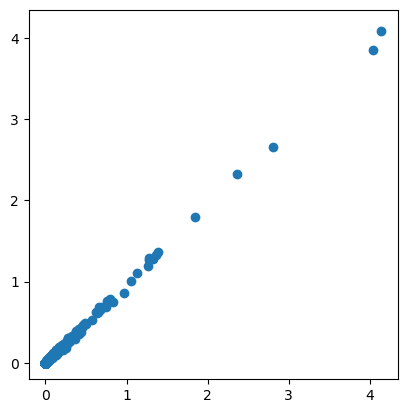

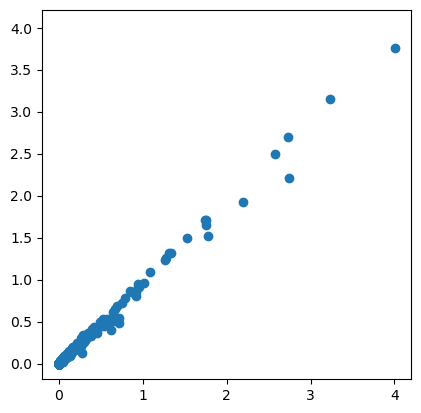

In [44]:
trace = diva_trainer.get_trace('test')
print(-1 * trace.nodes['rec']['fn'].log_prob(test_set[:][0]).mean().item())
plt.figure()
plt.scatter(test_set[:][0].log1p().mean(dim=0), recons.log1p().mean(dim=0))
plt.gca().axis('square')

plt.figure()
plt.scatter(test_set[:][0].log1p().var(dim=0), recons.log1p().var(dim=0))
plt.gca().axis('square')


plt.show()

In [45]:
reducer = UMAP()
z_s = reducer.fit_transform(z_s)

C:\Users\anany\miniconda3\envs\ds_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


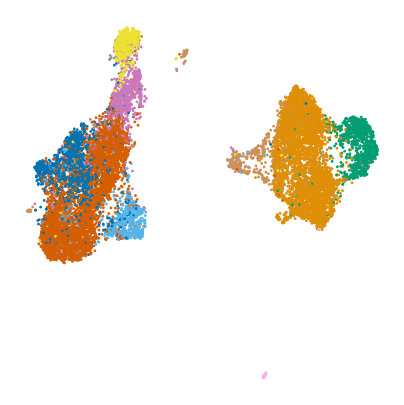

In [46]:
plt.figure(figsize=(5,5))
plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.axis('off')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())

plt.show()

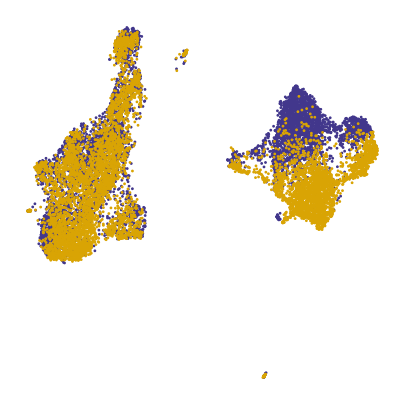

In [47]:
plt.figure(figsize=(5,5))
plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.axis('off')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())

plt.show()

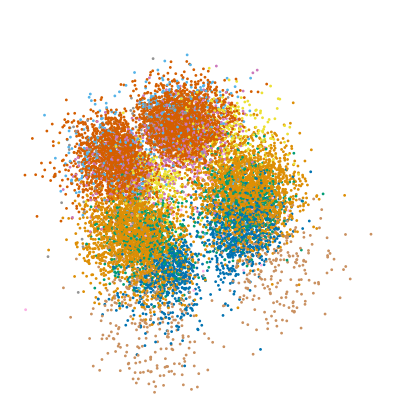

In [48]:
plt.figure(figsize=(5,5))
plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.axis('off')
plt.ylim(-7,7)
plt.xlim(-7,7)

plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.show()

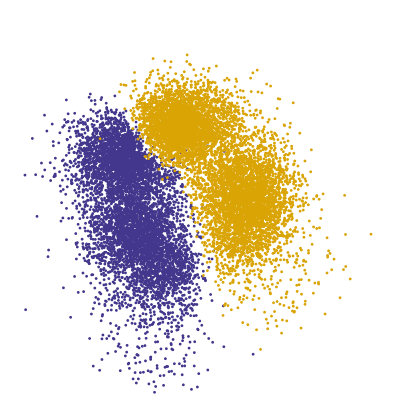

In [49]:
plt.figure(figsize=(5,5))
plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.axis('off')
plt.ylim(-7,7)
plt.xlim(-7,7)

plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.show()

## CCVAE

In [50]:
np.random.seed(42)
torch.manual_seed(42)
pyro.util.set_rng_seed(42)

ccvae = ZINBCCVAE(2000, [1], latent_dim=10, w_dim=2, num_layers=1, hidden_dim=128, recon_weight=1, kl_weight=1e-4)
ccvae_trainer = ThresholdPyroTrainer(0, 50, ccvae, train_loader, test_loader, opt.AdamW({"lr": 1e-3}))
ccvae_trainer.train()

Epoch : 1 || Train Loss: 682.229 || Test Loss: 412.816
Epoch : 2 || Train Loss: 394.373 || Test Loss: 393.376
New minimum attained, resetting patience...
Epoch : 3 || Train Loss: 379.241 || Test Loss: 375.641
New minimum attained, resetting patience...
Epoch : 4 || Train Loss: 369.884 || Test Loss: 367.63
New minimum attained, resetting patience...
Epoch : 5 || Train Loss: 365.166 || Test Loss: 364.182
New minimum attained, resetting patience...
Epoch : 6 || Train Loss: 360.839 || Test Loss: 357.736
New minimum attained, resetting patience...
Epoch : 7 || Train Loss: 357.918 || Test Loss: 355.912
New minimum attained, resetting patience...
Epoch : 8 || Train Loss: 356.121 || Test Loss: 354.744
New minimum attained, resetting patience...
Epoch : 9 || Train Loss: 354.316 || Test Loss: 353.426
New minimum attained, resetting patience...
Epoch : 10 || Train Loss: 352.861 || Test Loss: 350.284
New minimum attained, resetting patience...
Epoch : 11 || Train Loss: 351.602 || Test Loss: 349.34

In [51]:
preds = ccvae_trainer.get_variables('test')
z_s = preds['z'][0].cpu()
w_s = preds['w'][0].cpu()
recons = preds['rec'][0].cpu()

317.4369812011719


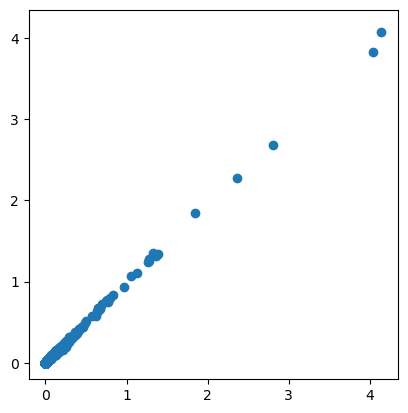

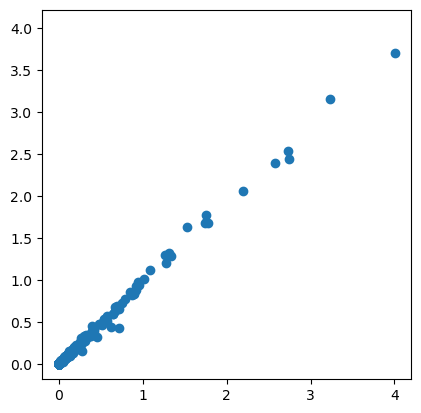

In [52]:
trace = ccvae_trainer.get_trace('test')
print(-1 * trace.nodes['rec']['fn'].log_prob(test_set[:][0]).mean().item())
plt.figure()
plt.scatter(test_set[:][0].log1p().mean(dim=0), recons.log1p().mean(dim=0))
plt.gca().axis('square')

plt.figure()
plt.scatter(test_set[:][0].log1p().var(dim=0), recons.log1p().var(dim=0))
plt.gca().axis('square')


plt.show()

In [53]:
reducer = UMAP()
z_s = reducer.fit_transform(z_s)

C:\Users\anany\miniconda3\envs\ds_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


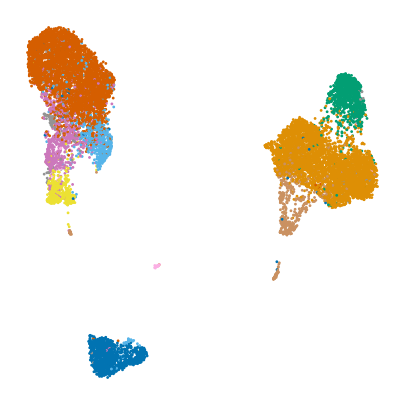

In [54]:
plt.figure(figsize=(5,5))
plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.axis('off')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.show()

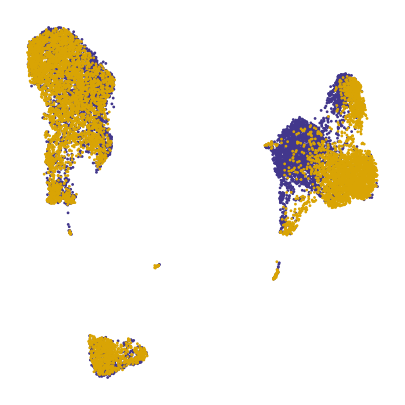

In [55]:
plt.figure(figsize=(5,5))
plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.axis('off')
plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.show()

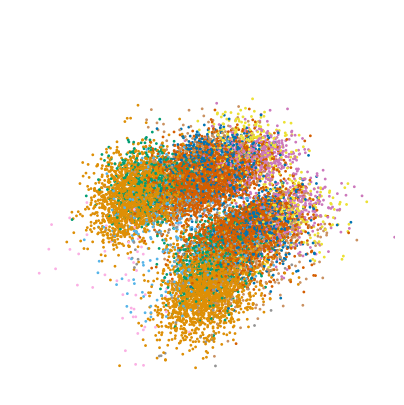

In [56]:
plt.figure(figsize=(5,5))
plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.axis('off')
plt.ylim(-7,7)
plt.xlim(-7,7)

plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.show()

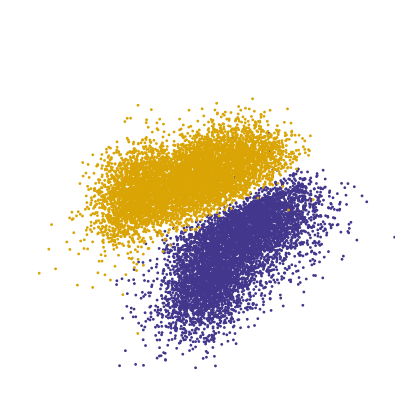

In [57]:
plt.figure(figsize=(5,5))
plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.axis('off')
plt.ylim(-7,7)
plt.xlim(-7,7)

plt.gca().set_aspect(1/plt.gca().get_data_ratio())
plt.show()

## DISCoVeR

In [58]:
np.random.seed(42)
torch.manual_seed(42)
pyro.util.set_rng_seed(42)

dlvae = ZINBDLVAE(2000, [1], latent_dim=10, w_dim=10, num_layers=0, hidden_dim=128, recon_weight=9e-1, recon_weight_z=1e-1, w_kl_weight=1e-4, z_kl_weight=1e-4, adversarial_weight=1e2, learnable_prior=False)
dlvae_trainer = AdversarialThresholdPyroTrainer(0, 50, 1, 1, dlvae, train_loader, test_loader, opt.AdamW({"lr": 1e-3}))
dlvae_trainer.train()

Epoch : 1 || Train Loss: 1136.492 || Test Loss: 565.684 || Classifier Loss: 0.648
Epoch : 2 || Train Loss: 517.245 || Test Loss: 479.218 || Classifier Loss: 0.658
New minimum attained, resetting patience...
Epoch : 3 || Train Loss: 466.093 || Test Loss: 450.834 || Classifier Loss: 0.648
New minimum attained, resetting patience...
Epoch : 4 || Train Loss: 450.465 || Test Loss: 425.752 || Classifier Loss: 0.675
New minimum attained, resetting patience...
Epoch : 5 || Train Loss: 431.096 || Test Loss: 421.038 || Classifier Loss: 0.68
New minimum attained, resetting patience...
Epoch : 6 || Train Loss: 419.173 || Test Loss: 417.91 || Classifier Loss: 0.711
New minimum attained, resetting patience...
Epoch : 7 || Train Loss: 411.312 || Test Loss: 401.72 || Classifier Loss: 0.664
New minimum attained, resetting patience...
Epoch : 8 || Train Loss: 400.562 || Test Loss: 393.562 || Classifier Loss: 0.66
New minimum attained, resetting patience...
Epoch : 9 || Train Loss: 390.204 || Test Loss: 

In [59]:
preds = dlvae_trainer.get_variables('test')
z_s = preds['z'][0].cpu()
w_s = preds['w'][0].cpu()
recons_w = preds['rec_w'][0].cpu()
recons_z = preds['rec_z'][0].cpu()

351.60333251953125
420.6676940917969


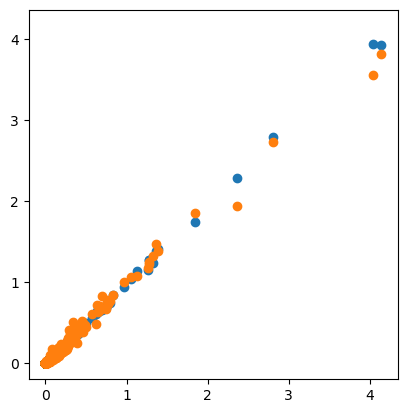

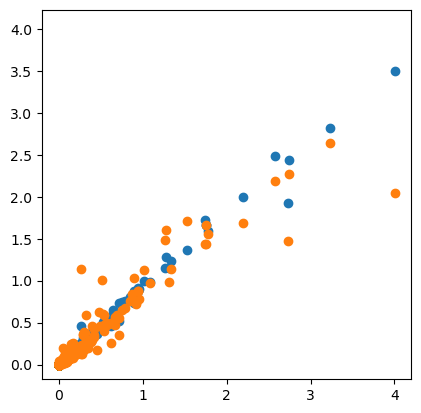

In [60]:
trace = dlvae_trainer.get_trace('test')
print(-1 * trace.nodes['rec_w']['fn'].log_prob(test_set[:][0]).mean().item())
print(-1 * trace.nodes['rec_z']['fn'].log_prob(test_set[:][0]).mean().item())

plt.figure()
plt.scatter(test_set[:][0].log1p().mean(dim=0), recons_w.log1p().mean(dim=0))
plt.scatter(test_set[:][0].log1p().mean(dim=0), recons_z.log1p().mean(dim=0))

plt.gca().axis('square')

plt.figure()
plt.scatter(test_set[:][0].log1p().var(dim=0), recons_w.log1p().var(dim=0))
plt.scatter(test_set[:][0].log1p().var(dim=0), recons_z.log1p().var(dim=0))
plt.gca().axis('square')


plt.show()

In [61]:
reducer = UMAP()
umap_recon_zs = reducer.fit_transform(torch.log1p(recons_z))
z_s = reducer.fit_transform(z_s)
w_s = reducer.fit_transform(w_s)

C:\Users\anany\miniconda3\envs\ds_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\anany\miniconda3\envs\ds_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\anany\miniconda3\envs\ds_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


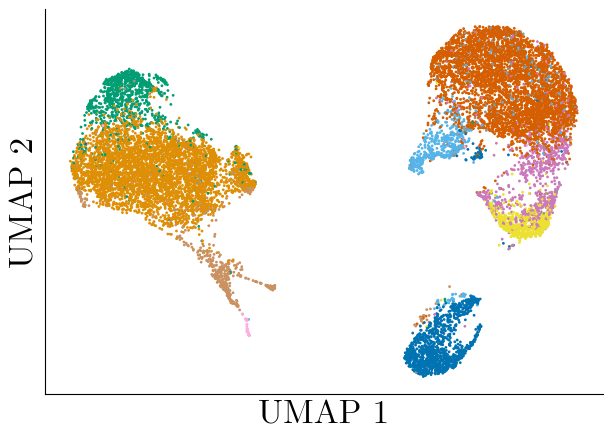

In [62]:
plt.figure(figsize=(10,5))
plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.gca().set_aspect('equal')
plt.yticks([])
plt.xticks([])
plt.gca().spines[['right', 'top']].set_visible(False)

plt.ylabel('UMAP 2', font=font, fontsize=24)
plt.xlabel('UMAP 1', font=font, fontsize=24)

plt.show()

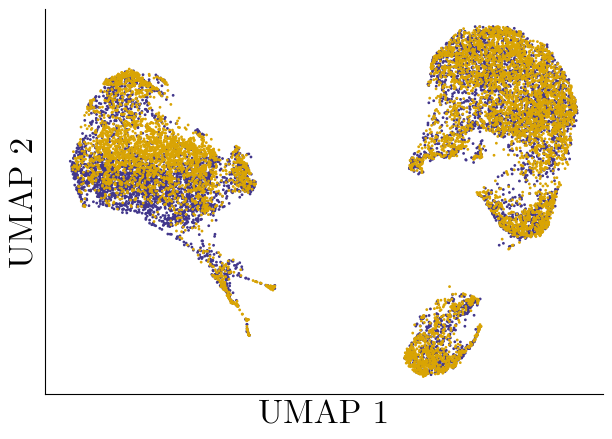

In [63]:
plt.figure(figsize=(10,5))
plt.scatter(z_s[:, 0], z_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.gca().set_aspect('equal')
plt.yticks([])
plt.xticks([])
plt.gca().spines[['right', 'top']].set_visible(False)

plt.ylabel('UMAP 2', font=font, fontsize=24)
plt.xlabel('UMAP 1', font=font, fontsize=24)

plt.show()

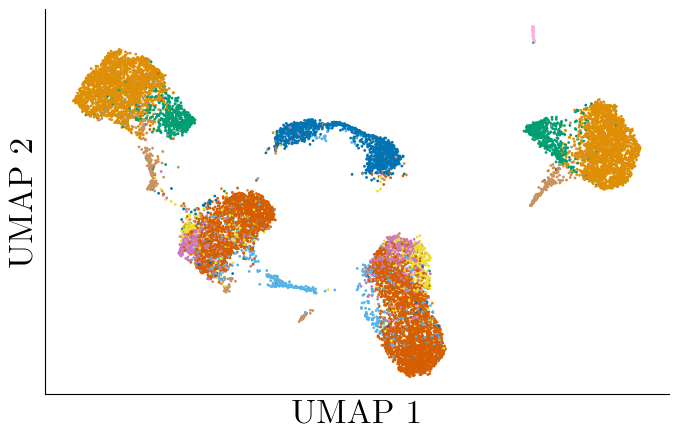

In [64]:
plt.figure(figsize=(10,5))
plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][2].numpy(), cmap=cmap_ct, s=1)
plt.gca().set_aspect('equal')
plt.yticks([])
plt.xticks([])
plt.gca().spines[['right', 'top']].set_visible(False)

plt.ylabel('UMAP 2', font=font, fontsize=24)
plt.xlabel('UMAP 1', font=font, fontsize=24)

plt.show()

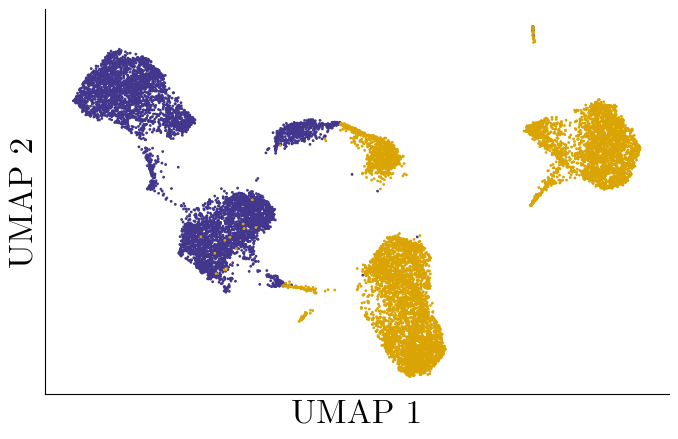

In [65]:
plt.figure(figsize=(10,5))
plt.scatter(w_s[:, 0], w_s[:, 1], c=test_set[:][1].numpy(), cmap=cmap_trt, s=1)
plt.gca().set_aspect('equal')
plt.yticks([])
plt.xticks([])
plt.gca().spines[['right', 'top']].set_visible(False)

plt.ylabel('UMAP 2', font=font, fontsize=24)
plt.xlabel('UMAP 1', font=font, fontsize=24)

plt.show()

# Mutual Information Scores

In [67]:
stim_labels = anndata.obs['stim'].cat.codes.values
# T00 -> 0, T06 -> 1, T12 -> 2, T18 -> 3
stim_labels = torch.tensor(stim_labels, dtype=torch.long)

celltype_labels = anndata.obs['seurat_annotations'].cat.codes.values
celltype_labels = torch.tensor(celltype_labels, dtype=torch.long)

In [68]:
sys.path.append("./FlatlandAndBeyond/GeometriclyAgnosticEvaluation/src/")
from agnostic_metrics import *
# Wally et al. (2025)
# Full citation in external folder

In [69]:
latents = {}
def get_latents(model, name):
    preds = dlvae_trainer.get_variables('test')
    z_s = preds['z'][0].cpu()
    w_s = preds['w'][0].cpu()
    latents[name] = [w_s, z_s]

In [70]:
latents = {}
def get_latents(model, name):
    preds = model.get_variables('test')
    z_s = preds['z'][0].cpu()
    w_s = preds['w'][0].cpu()
    latents[name] = {"w": w_s, "z": z_s}

In [71]:
get_latents(csvaena_trainer, 'csvae no adv')
get_latents(csvae_trainer, 'csvae')
get_latents(hcsvaena_trainer, 'hcsvae no adv')
get_latents(hcsvae_trainer, 'hcsvae')
get_latents(diva_trainer, 'diva')
get_latents(ccvae_trainer, 'ccvae')
get_latents(dlvae_trainer, 'discover')

In [1]:
mi_dict = {}

def print_all_MI(model, keyval):
    # w_s = keyval['w']
    # z_s = keyval['z']
    z_norm = get_normalized_distance(keyval['z'])
    w_norm = get_normalized_distance(keyval['w'])
    mi_dict[model] = {}
    calculate_MI(model, z_norm, w_norm)
    # calculate_MI(model, z_norm, 'z', stim_labels, 'stim')
    # calculate_MI(model, z_norm, 'z', celltype_labels, 'cell type')
    # calculate_MI(model, w_norm, 'w', stim_labels, 'stim')
    # calculate_MI(model, w_norm, 'w', celltype_labels, 'cell type')

def calculate_MI(model, z, w):
    stim_distance = compute_categorical_distance(stim_labels.cpu().numpy(), discrete_dist=1)
    celltype_distance = compute_categorical_distance(celltype_labels.cpu().numpy(), discrete_dist=1)
    distances = np.concatenate(
        [z.cpu().numpy()[None, :, :], 
         w.cpu().numpy()[None, :, :], 
         stim_distance[None, :, :], 
         celltype_distance[None, :, :]],
        axis=0)
    mi_wz = cmi([1], [0], [], 5, distances, precomputed=True)
    mi_zstim = cmi([0], [2], [], 5, distances, precomputed=True)
    mi_zcelltype = cmi([0], [3], [], 5, distances, precomputed=True)
    mi_wstim = cmi([1], [2], [], 5, distances, precomputed=True)
    mi_wcelltype = cmi([1], [3], [], 5, distances, precomputed=True)
    mi_dict[model]["I(w,stim)"] = mi_wstim
    mi_dict[model]["I(w,celltype)"] = mi_wcelltype
    mi_dict[model]["I(z,stim)"] = mi_zstim
    mi_dict[model]["I(z,celltype)"] = mi_zcelltype
    mi_dict[model]["I(w,z)"] = mi_wz

# def calculate_MI(model, latent, latent_str, labels, label_str):
#     label_distance = compute_categorical_distance(labels.cpu().numpy(), discrete_dist=1)
#     distances = np.concatenate([latent.cpu().numpy()[None, :, :], label_distance[None, :, :]], axis=0)
#     mi = cmi([0], [1], [], 5, distances, precomputed=True)
#     mi_dict[model][f"I({latent_str},{label_str})"] = mi

def get_normalized_distance(var):
    var_tensor = torch.tensor(var, dtype=torch.float32)
    euclidean_var = get_pairwise_euclidean_distance(var_tensor)
    normalized_var = normalise_distances(euclidean_var)
    return normalized_var

In [2]:
for model, vals in latents.items():
    print_all_MI(model, vals)

NameError: name 'latents' is not defined

In [87]:
df = pd.DataFrame(mi_dict)
print(df.transpose())

               I(w,stim)  I(w,celltype)  I(z,stim)  I(z,celltype)    I(w,z)
csvae no adv    0.690767       0.690767   0.361862       0.361862  0.381784
csvae           0.691244       0.691244   0.009354       0.009354  0.037714
hcsvae no adv   0.690743       0.690743   0.276890       0.276890  0.268547
hcsvae          0.690645       0.690645   0.007606       0.007606  0.015643
diva            0.670366       0.670366   0.358816       0.358816  1.158627
ccvae           0.673784       0.673784   0.268698       0.268698  1.066973
discover        0.681363       0.681363   0.175519       0.175519  2.330181


In [81]:
csvaena_trainer.save('params/csvaena_stim')
csvae_trainer.save('params/csvae_stim')
hcsvaena_trainer.save('params/hcsvaena_stim')
hcsvae_trainer.save('params/hcsvae_stim')
ccvae_trainer.save('params/ccvae_stim')
diva_trainer.save('params/diva_stim')
dlvae_trainer.save('params/dlvae_stim')

In [88]:
# new_discover = ZINBDLVAE(2000, [1], latent_dim=10, w_dim=10, num_layers=0, hidden_dim=128, recon_weight=9e-1, recon_weight_z=1e-1, w_kl_weight=1e-4, z_kl_weight=1e-4, adversarial_weight=1e2, learnable_prior=False)
# new_discover_trainer = AdversarialThresholdPyroTrainer(0, 50, 1, 1, dlvae, train_loader, test_loader, opt.AdamW({"lr": 1e-3}))

In [99]:
# from torch.serialization import add_safe_globals
# import torch.distributions.constraints as constraints

# # Allow all common Pyro constraint classes
# add_safe_globals([
#     constraints._GreaterThan,
#     constraints._LessThan,
#     constraints._Interval,
#     # constraints._Positive,
#     constraints._Real,
#     constraints._Simplex,
#     # constraints._UnitInterval,
#     # constraints._BatchedMultivariateNormal,
# ])
# new_discover_trainer.load('params/dlvae_stim')

In [101]:
# @inproceedings{
# wally2025flatland,
# title={Flatland and Beyond: Mutual Information Across Geometries},
# author={Youssef Wally and Johan Mylius-Kroken and Michael Kampffmeyer and Rezvan Ehsani and Vladan Milosevic and Elisabeth Wetzer},
# booktitle={2nd Beyond Euclidean Workshop: Hyperbolic and Hyperspherical Learning for Computer Vision},
# year={2025},
# url={https://openreview.net/forum?id=LX9bskkzH2}
# }